In [1]:
import os
import numpy as np
import pandas as pd

curfolder = os.getcwd()

# load in the df feature_extraction_with2d_extended
data = pd.read_csv(os.path.join(curfolder, 'feature_extraction_with2d_extended.csv'))


In [2]:
data.head()

,participantID,Age,BirthPlace,Gender,NativeLanguages,NumOfNativeLanguages,Other Languages,TotalLanguages,Extroversion,Hand,...,total_arms_time,total_legs_time,total_time,RIGHT_WRIST_SpeedAVG,LEFT_WRIST_SpeedAVG,RIGHT_WRIST_AccelAVG,LEFT_WRIST_AccelAVG,RIGHT_WRIST_SpeedSD,LEFT_WRIST_SpeedSD,RIGHT_WRIST_AccelSD
0,23,35.0,Deutschland,Woman / Weiblich,Deutsch,1.0,"English (fluent), French (advanced), Italian (...",4.0,43.0,Right-handed / Rechtshänder*in,...,4250.000000,2683.333333,3783.333333,0.000286,0.000311,-1.087172e-06,-7.159594e-07,0.000275,0.000283,0.000019
1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2683.333333,0.000000,2683.333333,0.000202,0.000184,-3.634087e-06,-2.515463e-06,0.000176,0.000163,0.000013
2,16,27.0,Deutschland,Man / Männlich,Deutsch,1.0,English,2.0,30.0,Right-handed / Rechtshänder*in,...,7516.666667,5966.666667,5966.666667,0.000357,0.000376,2.469870e-08,-5.828587e-08,0.000267,0.000277,0.000036
3,22,32.0,"Delft, Netherlands",Man / Man,Dutch and Polish,NaN,"English (fluent), French (good knowledge), Ger...",5.0,91.0,Right-handed / Rechtshandig,...,3533.333333,0.000000,2600.000000,0.000048,0.000457,-1.972671e-07,-1.704389e-06,0.000026,0.000335,0.000026
4,30,45.0,Dresden,Woman / Weiblich,Deutsch,1.0,Englisch,2.0,51.0,Right-handed / Rechtshänder*in,...,6583.333333,6583.333333,6583.333333,0.000131,0.000153,-9.870093e-08,-5.883288e-07,0.000144,0.000169,0.000012


C:\Users\kadava\AppData\Local\Temp\ipykernel_26984\4009210014.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset['chain_number'] = subset['chain_number'].astype(int)
C:\Users\kadava\AppData\Local\Temp\ipykernel_26984\4009210014.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset['event'] = subset['gesture'].apply(lambda x: 'Location A' if 'lndw' in x else 'Location B')


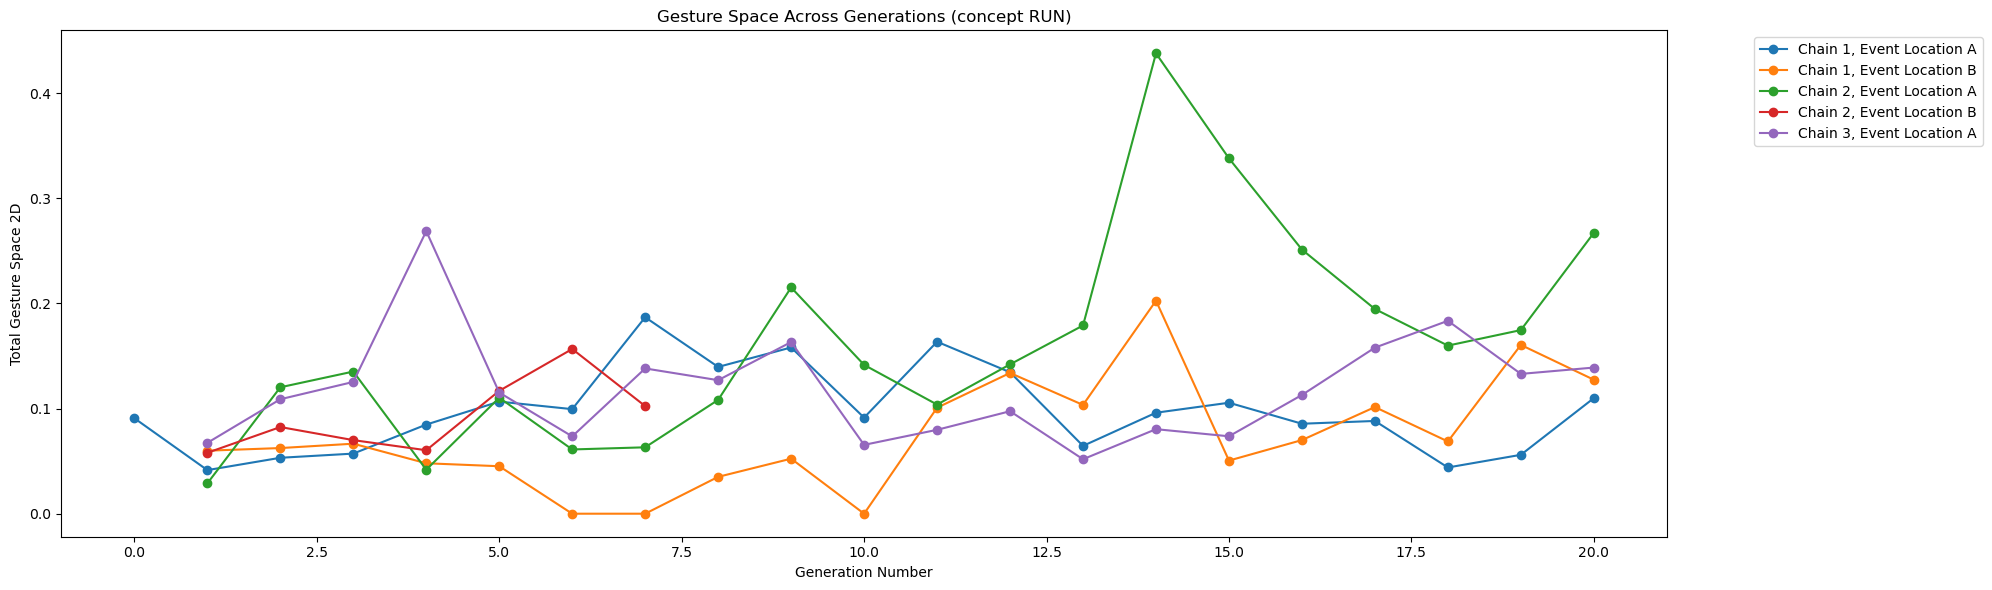

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 6))

# Filter to only the two gestures you care about
subset = data[data['gesture'].isin(['lndw_lndw_rennen', 'nijmegen_nijmegen_rennen'])]

# redo chain_number to integer (without decimal)
subset['chain_number'] = subset['chain_number'].astype(int)

# redo event, if lndw=Location A, if nijmegen=Location B
subset['event'] = subset['gesture'].apply(lambda x: 'Location A' if 'lndw' in x else 'Location B')

# Optional: define markers for two events
event_markers = {0: 'o', 1: 's'}   # change 0/1 to your actual event labels if needed

for (chain, event), group in subset.groupby(['chain_number', 'event']):
    group = group.sort_values('generation_number')  # ensure proper line order
    
    plt.plot(
        group['generation_number'],
        group['total_gesture_space2D'],
        marker=event_markers.get(event, 'o'),
        label=f'Chain {chain}, Event {event}'
    )

plt.xlabel('Generation Number')
plt.ylabel('Total Gesture Space 2D')
plt.title('Gesture Space Across Generations (concept RUN)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')  # moves legend outside if crowded
plt.tight_layout()
plt.show()


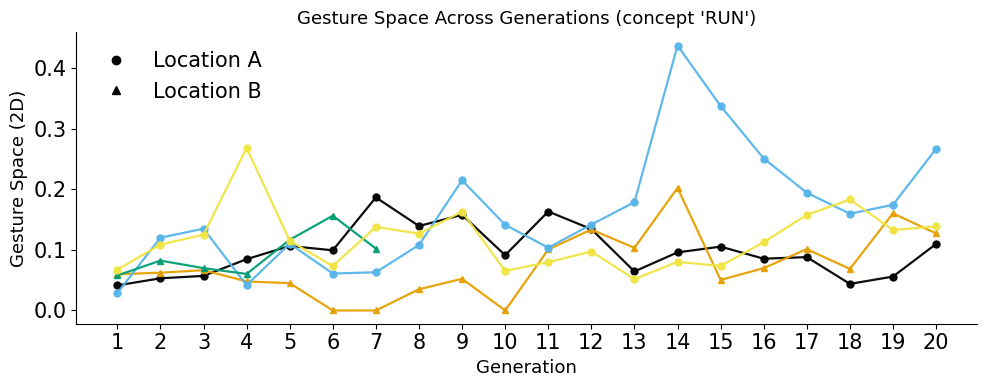

In [24]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
import colorsys

# ---------- Styling (bigger ticks + legend, still clean) ----------
plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 13,      # slightly larger axis labels
    "xtick.labelsize": 15,     # bigger ticks
    "ytick.labelsize": 15,     # bigger ticks
    "legend.fontsize": 15,    # bigger legend
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# ---------- Data prep ----------
subset = data[data['gesture'].isin(['lndw_lndw_rennen', 'nijmegen_nijmegen_rennen'])].copy()

# get rid of generation number 0
subset = subset[subset['generation_number'] > 0]

subset['chain_number'] = subset['chain_number'].astype(int)
subset['event'] = subset['gesture'].apply(lambda x: 'Location A' if 'lndw' in x else 'Location B')

event_markers = {
    "Location A": "o",   # circle
    "Location B": "^"    # triangle
}

groups = list(subset.groupby(['chain_number', 'event']))
n_groups = len(groups)

# ---------- High-contrast, color-blind friendly colors ----------
okabe_ito = [
    "#000000",
    "#E69F00",
    "#56B4E9",
    "#009E73",
    "#F0E442",
    "#0072B2",
    "#D55E00",
    "#CC79A7",
]

def distinct_colors(n):
    if n <= len(okabe_ito):
        return okabe_ito[:n]
    else:
        extra = n - len(okabe_ito)
        hues = np.linspace(0, 1, extra, endpoint=False)
        return okabe_ito + [colorsys.hsv_to_rgb(h, 0.75, 0.85) for h in hues]

colors = distinct_colors(n_groups)

# ---------- Plot ----------
plt.figure(figsize=(10, 4))

for i, ((chain, event), group) in enumerate(groups):
    group = group.sort_values('generation_number')

    plt.plot(
        group['generation_number'],
        group['total_gesture_space2D'],
        color=colors[i],
        marker=event_markers[event],
        linewidth=1.6,
        markersize=5,
        alpha=0.95
    )

# ---------- Axes formatting ----------
gens = np.sort(subset['generation_number'].unique())
plt.xticks(gens)

plt.xlabel("Generation")
plt.ylabel("Gesture Space (2D)")
plt.title("Gesture Space Across Generations (concept 'RUN')")

# ---------- Minimal legend ----------
legend_elements = [
    Line2D([0], [0], marker='o', color='black', linestyle='None', label='Location A'),
    Line2D([0], [0], marker='^', color='black', linestyle='None', label='Location B'),
]

plt.legend(handles=legend_elements, frameon=False, loc="upper left")

plt.tight_layout()
plt.show()
